# importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Importing Dataset

In [4]:
df=pd.read_csv("Customer Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# replacing blanks in TotalCharges with 0 as tenure is 0 and no total charges are recorded.

In [8]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum().sum()

0

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
df["customerID"].duplicated().sum()

0

In [16]:
df["SeniorCitizen"] = df["SeniorCitizen"].replace({0:'No',1:'yes'})

In [19]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# here we will replace the 0 and 1 in SeniorCitizen with Yes/No to make it easily understandable

In [20]:
df["SeniorCitizen"]= df["SeniorCitizen"].replace("yes","Yes")

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


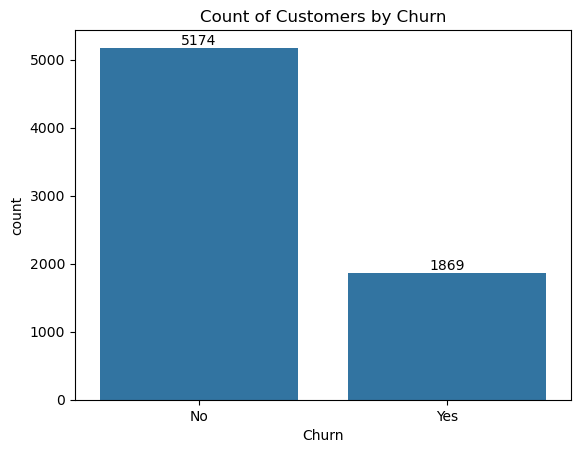

In [ ]:
ax= sns.countplot(x='Churn', data=df)

ax.bar_label(ax.containers[0])  # 0 is the indwx here
plt.title("Count of Customers by Churn")

plt.show()

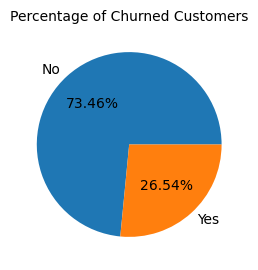

In [34]:
plt.figure(figsize=(3,3))
gb= df.groupby("Churn").agg({'Churn':"count"})  # count will written as count here only as it is being used as counting purpose not as Count because this will through an error.
plt.pie(gb['Churn'], labels= gb.index, autopct="%1.2f%%")
plt.title("Percentage of Churned Customers" , fontsize=10)
plt.show()

# from the above pie chart we can conclude that 26.54% customers have churrned out .
# Now lets explore the reason behind it.

<Figure size 300x300 with 0 Axes>

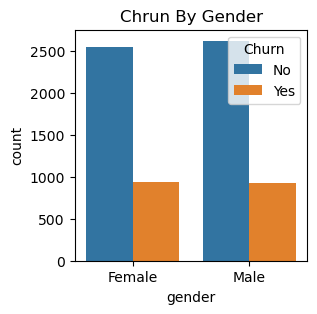

In [36]:
plt.figure(figsize= (3,3))
sns.countplot(x= "gender", data= df, hue= "Churn")
plt.title("Chrun By Gender")
plt.show()

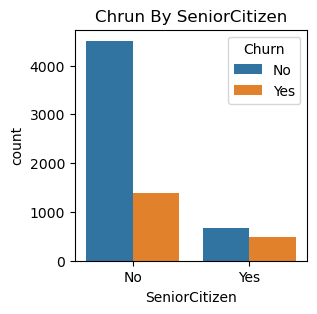

In [37]:
plt.figure(figsize= (3,3))
sns.countplot(x= "SeniorCitizen", data= df, hue= "Churn")
plt.title("Chrun By SeniorCitizen")
plt.show()

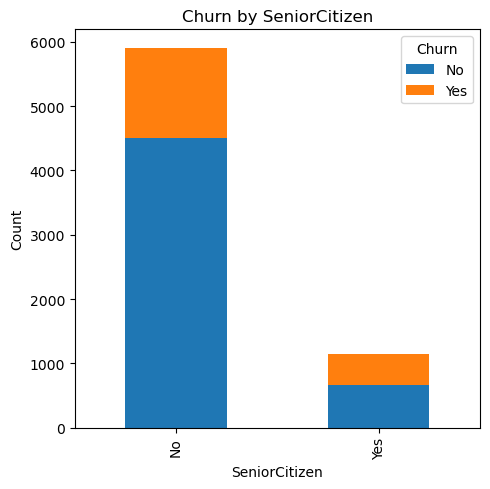

In [ ]:
# Create a crosstab of the counts
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Plot as a stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(5,5), color=["#1f77b4", "#ff870e"])  # optional: custom colors
plt.title("Churn by SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()

plt.show()

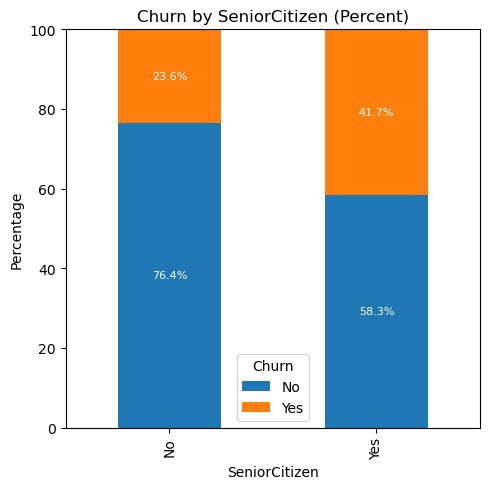

In [43]:
# Step 1: Calculate counts and convert to percentage
counts = pd.crosstab(df['SeniorCitizen'], df['Churn'])
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Step 2: Plot stacked bar chart of percentages
ax = percentages.plot(kind='bar', stacked=True, figsize=(5, 5), color=["#1f77b4", "#ff7f0e"])
plt.title("Churn by SeniorCitizen (Percent)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")

# Step 3: Add percentage labels inside each stacked bar
for i, (index, row) in enumerate(percentages.iterrows()):
    cumulative = 0
    for j, value in enumerate(row):
        if value > 0:
            ax.text(
                i, cumulative + value / 2,         # Position in the middle of each segment
                f"{value:.1f}%",                   # Format as percent
                ha='center', va='center', fontsize=8, color='white'
            )
            cumulative += value

plt.ylim(0, 100)  # Ensure y-axis is percent
plt.tight_layout()
plt.show()

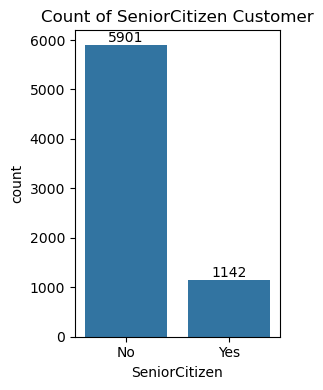

In [49]:
plt.figure(figsize= (3,4))
ax= sns.countplot(x= "SeniorCitizen", data= df)
ax.bar_label(ax.containers[0])
plt.title("Count of SeniorCitizen Customer")
plt.tight_layout()
plt.show()

# Comparitively a large number of people in senior citizen category have churnned out.

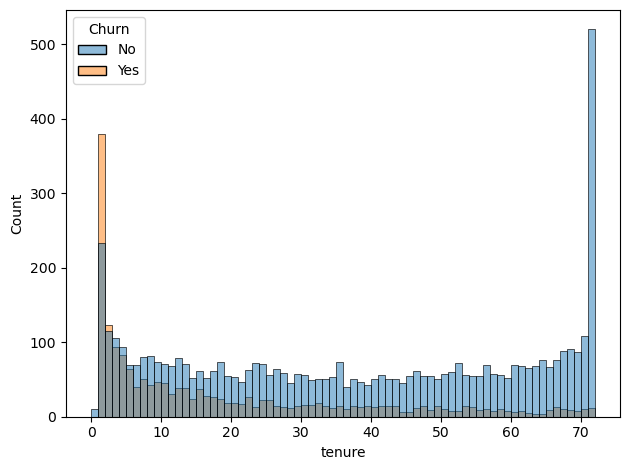

In [ ]:
sns.histplot(x= "tenure", data= df, bins= 72, hue= "Churn")
plt.Figure(figsize=(35,25))
plt.tight_layout()
plt.show()

# People who have used the services for longer time have stayed while the people who used the services for as short as of one or two months churned.